## Pipeline for all complex tissue datasets

In [1]:
# please specify which dataset you want to process:
# available options: PBMC, WBC, PFC
dataset = "PBMC"

# please specifiy path for reading input files
PATH = dataset.lower()

In [2]:
import subprocess
import os
import zipfile

dataset_dir = os.path.join(dataset.lower())
os.makedirs(dataset_dir, exist_ok=True)

def download_if_needed(url, target_dir):
    filename = url.split("/")[-1]

    if "figshare.com" in url:
        filename = "raw.zip"

    output_path = os.path.join(target_dir, filename)

    if os.path.exists(output_path):
        print(f"File exists – resume if needed: {filename}")
        subprocess.run([
            "curl", "-L", "-C", "-", "-o", output_path, url
        ], check=True)
    else:
        print(f"Download: {filename}")
        subprocess.run([
            "curl", "-L", "-o", output_path, url
        ], check=True)

def download_pfc_if_needed(url, base_dir, filename):
    if "filtered" in filename:
        target_dir = os.path.join(base_dir, "filtered")
    elif "raw" in filename:
        target_dir = os.path.join(base_dir, "raw")
    else:
        target_dir = base_dir
    os.makedirs(target_dir, exist_ok=True)
    output_path = os.path.join(target_dir, filename)

    if os.path.exists(output_path):
        print(f"Resume: {filename}")
        subprocess.run([
            "curl", "-L", "-C", "-", "--fail",
            "-o", output_path, url
        ], check=True)
    else:
        print(f"Download: {filename}")
        subprocess.run([
            "curl", "-L", "--fail",
            "-o", output_path, url
        ], check=True)

def extract_gz_files(directory):
    for filename in os.listdir(directory):
        if filename.endswith(".gz"):
            filepath = os.path.join(directory, filename)

            print(f"Extracting (gunzip): {filename}")

            subprocess.run([
                "gunzip", "-f", filepath  
            ], check=True)

def extract_flat(zip_path, target_dir):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        for member in zip_ref.namelist():
            # nur Dateien (keine Ordner)
            if not member.endswith("/"):
                filename = os.path.basename(member)  # entfernt "raw/"
                target_path = os.path.join(target_dir, filename)

                with open(target_path, "wb") as f:
                    f.write(zip_ref.read(member))

if dataset == "PBMC":
    urls = [
        "https://cf.10xgenomics.com/samples/cell-exp/9.0.0/60k_Human_TotalSeqB_hashing_3p_gem-x_Human_Donor1_PBMC_TotalSeqB_hashing_3p_gem-x/60k_Human_TotalSeqB_hashing_3p_gem-x_Human_Donor1_PBMC_TotalSeqB_hashing_3p_gem-x_count_sample_filtered_feature_bc_matrix.h5",
        "https://cf.10xgenomics.com/samples/cell-exp/9.0.0/60k_Human_TotalSeqB_hashing_3p_gem-x_Human_Donor2_PBMC_TotalSeqB_hashing_3p_gem-x/60k_Human_TotalSeqB_hashing_3p_gem-x_Human_Donor2_PBMC_TotalSeqB_hashing_3p_gem-x_count_sample_filtered_feature_bc_matrix.h5",
        "https://cf.10xgenomics.com/samples/cell-exp/9.0.0/60k_Human_TotalSeqB_hashing_3p_gem-x_Human_Donor3_PBMC_TotalSeqB_hashing_3p_gem-x/60k_Human_TotalSeqB_hashing_3p_gem-x_Human_Donor3_PBMC_TotalSeqB_hashing_3p_gem-x_count_sample_filtered_feature_bc_matrix.h5",
        "https://cf.10xgenomics.com/samples/cell-exp/9.0.0/60k_Human_TotalSeqB_hashing_3p_gem-x_Human_Donor4_PBMC_TotalSeqB_hashing_3p_gem-x/60k_Human_TotalSeqB_hashing_3p_gem-x_Human_Donor4_PBMC_TotalSeqB_hashing_3p_gem-x_count_sample_filtered_feature_bc_matrix.h5",
        "https://cf.10xgenomics.com/samples/cell-exp/9.0.0/60k_Human_TotalSeqB_hashing_3p_gem-x_Multiplex/60k_Human_TotalSeqB_hashing_3p_gem-x_Multiplex_count_raw_feature_bc_matrix.h5"
    ]

elif dataset == "WBC":
    urls = [
        "https://ndownloader.figshare.com/files/41209533",
    ]

elif dataset == "PFC":
    urls = [
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138509&format=file&file=GSM5138509_RL2103_ga22_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138509_ga22_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138509&format=file&file=GSM5138509_RL2103_ga22_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138509_ga22_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138511&format=file&file=GSM5138511_RL2107_ga24_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138511_ga24_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138511&format=file&file=GSM5138511_RL2107_ga24_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138511_ga24_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138513&format=file&file=GSM5138513_RL2121_ga34_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138513_ga34_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138513&format=file&file=GSM5138513_RL2121_ga34_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138513_ga34_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138514&format=file&file=GSM5138514_RL1777_1m_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138514_1m_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138514&format=file&file=GSM5138514_RL1777_1m_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138514_1m_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138516&format=file&file=GSM5138516_RL1612_2m_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138516_2m_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138516&format=file&file=GSM5138516_RL1612_2m_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138516_2m_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138517&format=file&file=GSM5138517_RL2100_3m_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138517_3m_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138517&format=file&file=GSM5138517_RL2100_3m_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138517_3m_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138519&format=file&file=GSM5138519_RL2104_4m_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138519_4m_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138519&format=file&file=GSM5138519_RL2104_4m_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138519_4m_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138520&format=file&file=GSM5138520_RL2108_6m_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138520_6m_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138520&format=file&file=GSM5138520_RL2108_6m_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138520_6m_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138522&format=file&file=GSM5138522_RL2122_10m_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138522_10m_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138522&format=file&file=GSM5138522_RL2122_10m_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138522_10m_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138524&format=file&file=GSM5138524_RL2125_1y_a_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138524_1y_a_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138524&format=file&file=GSM5138524_RL2125_1y_a_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138524_1y_a_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138528&format=file&file=GSM5138528_RL1613_2y_a_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138528_2y_a_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138528&format=file&file=GSM5138528_RL1613_2y_a_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138528_2y_a_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138530&format=file&file=GSM5138530_RL2129_3y_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138530_3y_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138530&format=file&file=GSM5138530_RL2129_3y_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138530_3y_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138531&format=file&file=GSM5138531_RL2109_4y_snRNAseq_filtered_bc_matrix.h5.gz", "GSM5138531_4y_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138531&format=file&file=GSM5138531_RL2109_4y_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138531_4y_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138533&format=file&file=GSM5138533_RL2106_6y_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138533_6y_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138533&format=file&file=GSM5138533_RL2106_6y_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138533_6y_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138535&format=file&file=GSM5138535_RL1614_8y_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138535_8y_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138535&format=file&file=GSM5138535_RL1614_8y_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138535_8y_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138537&format=file&file=GSM5138537_RL2110_10y_a_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138537_10y_a_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138537&format=file&file=GSM5138537_RL2110_10y_a_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138537_10y_a_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138540&format=file&file=GSM5138540_RL2127_12y_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138540_12y_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138540&format=file&file=GSM5138540_RL2127_12y_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138540_12y_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138541&format=file&file=GSM5138541_RL2130_14y_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138541_14y_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138541&format=file&file=GSM5138541_RL2130_14y_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138541_14y_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138543&format=file&file=GSM5138543_RL2102_16y_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138543_16y_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138543&format=file&file=GSM5138543_RL2102_16y_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138543_16y_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138545&format=file&file=GSM5138545_RL2131_17y_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138545_17y_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138545&format=file&file=GSM5138545_RL2131_17y_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138545_17y_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138546&format=file&file=GSM5138546_RL2123_20y_a_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138546_20y_a_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138546&format=file&file=GSM5138546_RL2123_20y_a_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138546_20y_a_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138549&format=file&file=GSM5138549_RL2132_25y_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138549_25y_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138549&format=file&file=GSM5138549_RL2132_25y_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138549_25y_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138551&format=file&file=GSM5138551_RL2124_40y_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138551_40y_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138551&format=file&file=GSM5138551_RL2124_40y_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138551_40y_raw.h5.gz"),
    ]


else:
    raise ValueError("Unknown dataset")

if dataset == "PBMC":
    for url in urls:
        download_if_needed(url, dataset_dir)
elif dataset == "WBC":
    for url in urls:
        download_if_needed(url, dataset_dir)    
    zip_path = os.path.join(dataset_dir, "raw.zip")
    extract_flat(zip_path, dataset_dir)
elif dataset == "PFC":
    for url, filename in urls:
        download_pfc_if_needed(url, dataset_dir, filename)
    extract_gz_files(os.path.join(dataset_dir, "filtered"))
    extract_gz_files(os.path.join(dataset_dir, "raw"))
else:
    raise ValueError("Dataset needs to beither PBMC, WBC or PFC!")

Download: 60k_Human_TotalSeqB_hashing_3p_gem-x_Human_Donor1_PBMC_TotalSeqB_hashing_3p_gem-x_count_sample_filtered_feature_bc_matrix.h5


  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed
100 38.78M 100 38.78M   0      0 10.37M      0   00:03   00:03          9.99M
  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed
  0      0   0      0   0      0      0      0                              0

Download: 60k_Human_TotalSeqB_hashing_3p_gem-x_Human_Donor2_PBMC_TotalSeqB_hashing_3p_gem-x_count_sample_filtered_feature_bc_matrix.h5


100 44.77M 100 44.77M   0      0 11.83M      0   00:03   00:03         11.78M
  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed
  0      0   0      0   0      0      0      0                              0

Download: 60k_Human_TotalSeqB_hashing_3p_gem-x_Human_Donor3_PBMC_TotalSeqB_hashing_3p_gem-x_count_sample_filtered_feature_bc_matrix.h5


100 36.30M 100 36.30M   0      0 11.75M      0   00:03   00:03         11.74M
  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed
  0      0   0      0   0      0      0      0                              0

Download: 60k_Human_TotalSeqB_hashing_3p_gem-x_Human_Donor4_PBMC_TotalSeqB_hashing_3p_gem-x_count_sample_filtered_feature_bc_matrix.h5


100 48.21M 100 48.21M   0      0 11.39M      0   00:04   00:04         11.34M
  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed
  0      0   0      0   0      0      0      0                              0

Download: 60k_Human_TotalSeqB_hashing_3p_gem-x_Multiplex_count_raw_feature_bc_matrix.h5


100 321.2M 100 321.2M   0      0 11.98M      0   00:26   00:26         12.23M


In [3]:
import scanpy as sc
import seaborn as sns
import numpy as np
import anndata as ad
from scipy.stats import median_abs_deviation
from matplotlib import pyplot as plt
import celltypist
from celltypist import models
import pandas as pd
from os import listdir
from scipy import io
import os

/home/luschroe/miniconda3/envs/benchmarking/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/home/luschroe/miniconda3/envs/benchmarking/lib/python3.11/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [4]:
file_paths = [
    f"{PATH}/60k_Human_TotalSeqB_hashing_3p_gem-x_Human_Donor1_PBMC_TotalSeqB_hashing_3p_gem-x_count_sample_filtered_feature_bc_matrix.h5",
    f"{PATH}/60k_Human_TotalSeqB_hashing_3p_gem-x_Human_Donor2_PBMC_TotalSeqB_hashing_3p_gem-x_count_sample_filtered_feature_bc_matrix.h5",
    f"{PATH}/60k_Human_TotalSeqB_hashing_3p_gem-x_Human_Donor3_PBMC_TotalSeqB_hashing_3p_gem-x_count_sample_filtered_feature_bc_matrix.h5",
    f"{PATH}/60k_Human_TotalSeqB_hashing_3p_gem-x_Human_Donor4_PBMC_TotalSeqB_hashing_3p_gem-x_count_sample_filtered_feature_bc_matrix.h5"
]

def load_and_concat_10x_pbmc(file_paths):
    """
    Loads all 10x h5 files from a directory and combines them into one AnnData object
    
    parameters
    ----------
    file_paths : list of str
        list with paths to AnnData objects
        
    returns
    -------
    adata : AnnData
        concatenated AnnData object with sample information
    """

    adatas = []

    for i, path in enumerate(file_paths):
        ada = sc.read_10x_h5(path)
        ada.var_names_make_unique()
        ada.obs['sample'] = f'sample_{i+1}'
        adatas.append(ada)

    adata = ad.concat(adatas, join="outer", label="sample", merge="first")

    return adata

In [5]:
def load_bd_data(matrix_path, barcodes_path, features_path, metadata_path):
    """
    Load BD Rhapsody single-cell data (MTX format) along with metadata into an AnnData object.

    Parameters
    ----------
    matrix_path : str
        Path to the matrix.mtx (can be gzipped).
    barcodes_path : str
        Path to the barcodes.tsv file.
    features_path : str
        Path to the genes/features.tsv file.
    metadata_path : str
        Path to the metadata.tsv file.

    Returns
    -------
    adata : anndata.AnnData
        AnnData object containing expression matrix, metadata, and gene annotations.
    """

    # Load sparse matrix and transpose (cells should be rows)
    X = io.mmread(matrix_path).tocsc().T

    # Load barcodes and convert to strings
    barcodes = pd.read_csv(barcodes_path, header=None, sep='\t')[0].astype(str)

    # Optionally create standardized cell names
    barcodes.index = [f"cell_{bc}" for bc in barcodes]

    # Load feature (gene) information
    features = pd.read_csv(features_path, header=None, sep='\t')
    gene_ids = features[0].values
    gene_names = features[1].values
    feature_types = features[2].values

    # Load metadata and align with barcodes
    metadata = pd.read_csv(metadata_path, sep='\t')
    metadata.index = metadata["CELL"]
    metadata = metadata.drop(columns=["CELL"])

    # Reorder metadata to match barcode order
    metadata = metadata.loc[barcodes]

    # Create AnnData object
    adata = ad.AnnData(X=X, obs=metadata)

    # Add gene annotations
    adata.var["gene_ids"] = gene_ids
    adata.var["gene_symbols"] = gene_names
    adata.var["feature_types"] = feature_types

    # Set gene names as variable names
    adata.var_names = gene_names  # alternatively: gene_ids

    # Set cell names
    adata.obs_names = barcodes.values  # should match metadata.index

    return adata

In [6]:
def load_and_concatenate_10x_pfc(data_in_path):
    """
    Loads all 10x h5 files from a directory and combines them into one AnnData object
    
    expected file format:
    RUNID_AGE_Chemistry_filetypename.h5
    
    parameters
    ----------
    data_in_path : str
        path to folder with .h5 files
        
    returns
    -------
    adata : AnnData
        concatenated AnnData object with batch information
    """

    file_list = np.sort(listdir(data_in_path))
    adata_list = []

    for fl_itr in file_list:
        fl_ids = fl_itr.split('_')

        adata_itr = sc.read_10x_h5(os.path.join(data_in_path, fl_itr), genome=None)

        # genome-Spalte entfernen (Problem bei concatenate)
        if 'genome' in adata_itr.var.columns:
            adata_itr.var.drop(labels='genome', axis=1, inplace=True)

        adata_itr.var['non-unique_names'] = adata_itr.var_names
        adata_itr.var_names_make_unique()

        adata_itr.obs['batch'] = "_".join(fl_ids[:2])
        adata_itr.obs['RL#'] = fl_ids[0]
        adata_itr.obs['age'] = fl_ids[1]

        adata_list.append(adata_itr)

    adata = sc.AnnData.concatenate(*adata_list, join='inner', batch_key="concat_id")

    # Barcodes neu formatieren
    barcodes = np.array([
        ii.split('-')[0] + '-' + jj
        for ii, jj in zip(adata.obs_names, adata.obs['batch'])
    ])
    adata.obs_names = barcodes

    return adata

In [7]:
# Load anndata object, 
if dataset == "WBC":
    adata_raw = load_bd_data(f"{PATH}/matrix.mtx", f"{PATH}/barcodes.tsv", f"{PATH}/genes.tsv", f"{PATH}/metadata.tsv")
    adata_raw.var_names_make_unique()
    adata_raw.obs['n_counts'] = adata_raw.X.sum(axis=1).A1
    adata = adata_raw[adata_raw.obs['n_counts'] > 500]
elif dataset == "PFC":
    adata_raw = load_and_concatenate_10x_pfc(f"{PATH}/raw")
    adata = load_and_concatenate_10x_pfc(f"{PATH}/filtered")
else:
    adata_raw = sc.read_10x_h5(f"{PATH}/60k_Human_TotalSeqB_hashing_3p_gem-x_Multiplex_count_raw_feature_bc_matrix.h5")
    adata_raw.var_names_make_unique()

    adata = load_and_concat_10x_pbmc(file_paths)

In [7]:
# save raw counts for compatibility with celltypist later
adata.layers["raw"] = adata.X.copy()

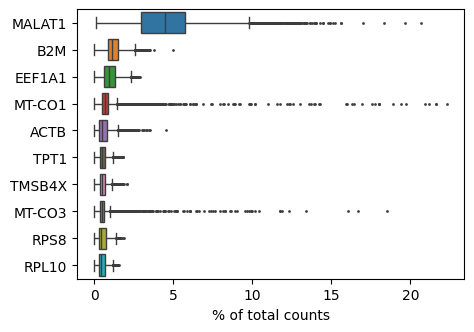

In [8]:
# inspect highest expressed genes
sc.pl.highest_expr_genes(adata, n_top=10)

### Quality Control

In [9]:
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [10]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)
adata

AnnData object with n_obs × n_vars = 39707 × 38606
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'genome', 'hashtag', 'pattern', 'read', 'sequence', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'raw'

... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'hashtag' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'sequence' as categorical


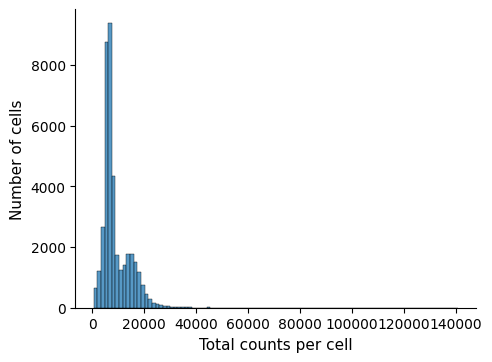

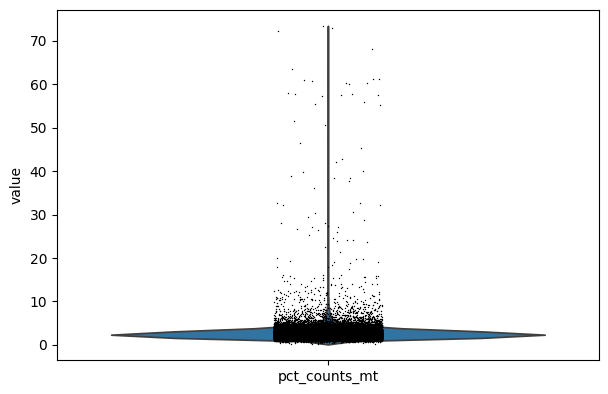

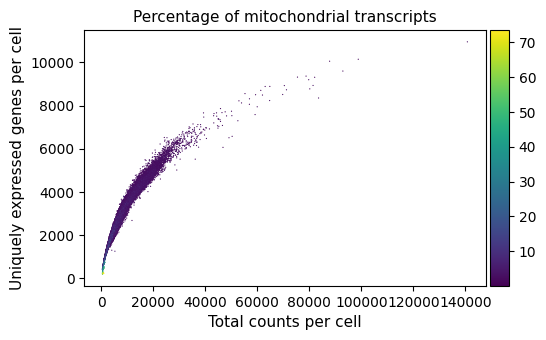

In [11]:
# plot quality metrics
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
p1.set_axis_labels("Total counts per cell", "Number of cells", fontsize=11)
p1.figure.set_size_inches(5, 3.5)
p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt", show=False)
p3.set_xlabel("Total counts per cell", fontsize=11)
p3.set_ylabel("Uniquely expressed genes per cell", fontsize=11)
p3.set_title("Percentage of mitochondrial transcripts", fontsize=11)
p3.figure.set_size_inches(6, 3.5)

In [12]:
# MAD tresholding
def is_outlier(adata, metric: str, nmads: int, batch_key: str = None):
    """
    Outlier detection based on MAD (global oder batch-aware).
    """
    values = adata.obs[metric]
    outlier_flags = pd.Series(False, index=adata.obs.index, dtype=bool)

    if batch_key is None:
        # global
        M = values
        med = np.median(M)
        mad = median_abs_deviation(M, scale=1)
        if mad > 0:
            outlier_flags[:] = (M < med - nmads * mad) | (M > med + nmads * mad)
    else:
        # batch-aware
        for batch, idx in adata.obs.groupby(batch_key).groups.items():
            M = values.loc[idx]   
            med = np.median(M)
            mad = median_abs_deviation(M, scale=1)
            if mad == 0:
                continue
            outliers = (M < med - nmads * mad) | (M > med + nmads * mad)
            outlier_flags.loc[idx] = outliers

    return outlier_flags

In [13]:
if dataset == "PBMC":
    key = None
elif dataset == "WBC":
    key = "Cartridge"
else:
    key = "batch"

adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", 5, batch_key=key)
    | is_outlier(adata, "log1p_n_genes_by_counts", 5, batch_key=key)
    | is_outlier(adata, "pct_counts_in_top_20_genes", 5, batch_key=key)
)
adata.obs.outlier.value_counts()

outlier
False    38841
True       866
Name: count, dtype: int64

In [14]:
# threshold differs between datasets
high_quality = ["PBMC", "PFC"]
if dataset in high_quality:
    threshold = 8
else:
    threshold = 20

adata.obs["mt_outlier"] = adata.obs["pct_counts_mt"] > threshold
adata.obs.mt_outlier.value_counts()

mt_outlier
False    39406
True       301
Name: count, dtype: int64

In [15]:
# remove outliers
print(f"Total number of cells: {adata.n_obs}")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()
print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")

Total number of cells: 39707
Number of cells after filtering of low quality cells: 38720


### Ambient RNA correction

#### SoupX

In [16]:
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import numpy2ri
import rpy2.robjects.packages as rpackages
from rpy2.robjects import r
from rpy2.robjects.packages import importr
import rpy2.rinterface_lib.callbacks as rcb
import logging

rcb.logger.setLevel(logging.ERROR)

%load_ext rpy2.ipython

cffi mode is CFFI_MODE.ANY
R home found: /home/luschroe/miniconda3/envs/benchmarking/lib/R
R library path: /home/luschroe/miniconda3/envs/benchmarking/lib:
LD_LIBRARY_PATH: /home/luschroe/miniconda3/envs/benchmarking/lib:
Default options to initialize R: rpy2, --quiet, --no-save
Environment variable "PWD" redefined by R and overriding existing variable. Current: "/mnt/c/Users/luki-/AppData/Local/Programs/Microsoft VS Code", R: "/home/luschroe/masterarbeit/Processing"
R is already initialized. No need to initialize.


In [17]:
# load R packages
r('''
library(SoupX)
library(Matrix)
''')


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

In [18]:
adata_pp = adata.copy()
sc.pp.normalize_per_cell(adata_pp)
sc.pp.log1p(adata_pp)

In [19]:
sc.pp.pca(adata_pp)
sc.pp.neighbors(adata_pp)
sc.tl.leiden(adata_pp, key_added="soupx_groups")

# Preprocess variables for SoupX
soupx_groups = adata_pp.obs["soupx_groups"]

In [20]:
del adata_pp

In [21]:
cells = adata.obs_names
genes = adata.var_names
data = adata.X.T

In [22]:
data_tod = adata_raw.X.T

In [23]:
del adata_raw

In [24]:
def scipy_csc_to_r_dgc(X, r_name):
    import numpy as np
    import scipy.sparse as sp
    from rpy2.robjects import IntVector, FloatVector, r

    if not sp.isspmatrix_csc(X):
        X = X.tocsc()

    X.sum_duplicates()
    X.sort_indices()

    r.assign("x", FloatVector(np.array(X.data, dtype=np.float64)))
    r.assign("i", IntVector(np.array(X.indices, dtype=np.int32)))
    r.assign("p", IntVector(np.array(X.indptr, dtype=np.int32)))
    r.assign("dims", IntVector(np.array(X.shape, dtype=np.int32)))

    r(f'''
    library(Matrix)
    {r_name} <- new("dgCMatrix", x = x, i = i, p = p, Dim = dims)
    ''')

In [25]:
scipy_csc_to_r_dgc(data, "data")
scipy_csc_to_r_dgc(data_tod, "data_tod")

In [26]:
%%R -i genes -i cells -i soupx_groups -o out 

# specify row and column names of data
rownames(data) = genes
colnames(data) = cells
rownames(data_tod) <- genes

# Generate SoupChannel Object for SoupX 
sc = SoupChannel(data_tod, data, calcSoupProfile = FALSE)

# Add extra meta data to the SoupChannel object
soupProf = data.frame(row.names = rownames(data), est = rowSums(data)/sum(data), counts = rowSums(data))
sc = setSoupProfile(sc, soupProf)
# Set cluster information in SoupChannel
sc = setClusters(sc, soupx_groups)

# Estimate contamination fraction
sc  = autoEstCont(sc, doPlot=FALSE)
# Infer corrected table of counts and rount to integer
out = adjustCounts(sc, roundToInt = TRUE)

2067 genes passed tf-idf cut-off and 278 soup quantile filter.  Taking the top 100.
Using 1633 independent estimates of rho.
Estimated global rho of 0.04
Expanding counts from 35 clusters to 38720 cells.
In addition: Warning message:
In sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w],  :
  'giveCsparse' is deprecated; setting repr="T" for you


In [27]:
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
import scipy.sparse

# R Packages
Matrix = importr("Matrix")

# 'out' is a R dgCMatrix object
# direct conversion to scipy.sparse.csc_matrix
out_python = scipy.sparse.csc_matrix(
    (list(ro.r('out@x')), list(ro.r('out@i')), list(ro.r('out@p'))), 
    shape=tuple(ro.r('dim(out)'))
)

In [28]:
# save corrected counts in layer and use corrected count matrix
adata.layers["corr"] = out_python.T
adata.X = adata.layers["corr"].copy()

In [29]:
# use float32 for compatibility with scrublet
adata.X = adata.X.astype(np.float32)
for layer in adata.layers:
    adata.layers[layer] = adata.layers[layer].astype(np.float32)

### Doublet Detection

In [30]:
# doublet detection using Scrublet
sc.pp.scrublet(adata, batch_key=key)

### Normalization

In [31]:
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
# log1p transform
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

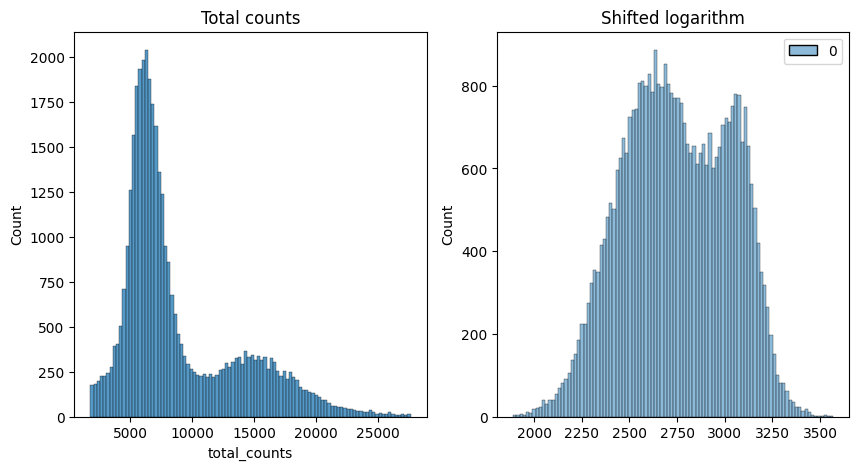

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

### Feature selection

In [33]:
# pca was calculated without hvgs!
sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=2000)

### Dimensionality Reduction

In [34]:
adata.X = adata.layers["log1p_norm"]

In [35]:
# scaling can improve PCA
sc.pp.scale(adata, max_value=10)

In [36]:
# use all genes not only hvgs
sc.pp.pca(adata, svd_solver="arpack", use_highly_variable=False)

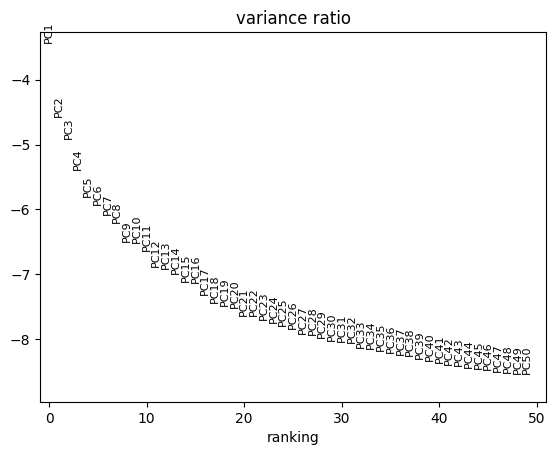

In [37]:
# compute variance ratio across Principal Component
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)

In [38]:
# compute tsne
sc.tl.tsne(adata, use_rep="X_pca")

In [39]:
# compute neighbors and umap
sc.pp.neighbors(adata, random_state=42)
sc.tl.umap(adata)

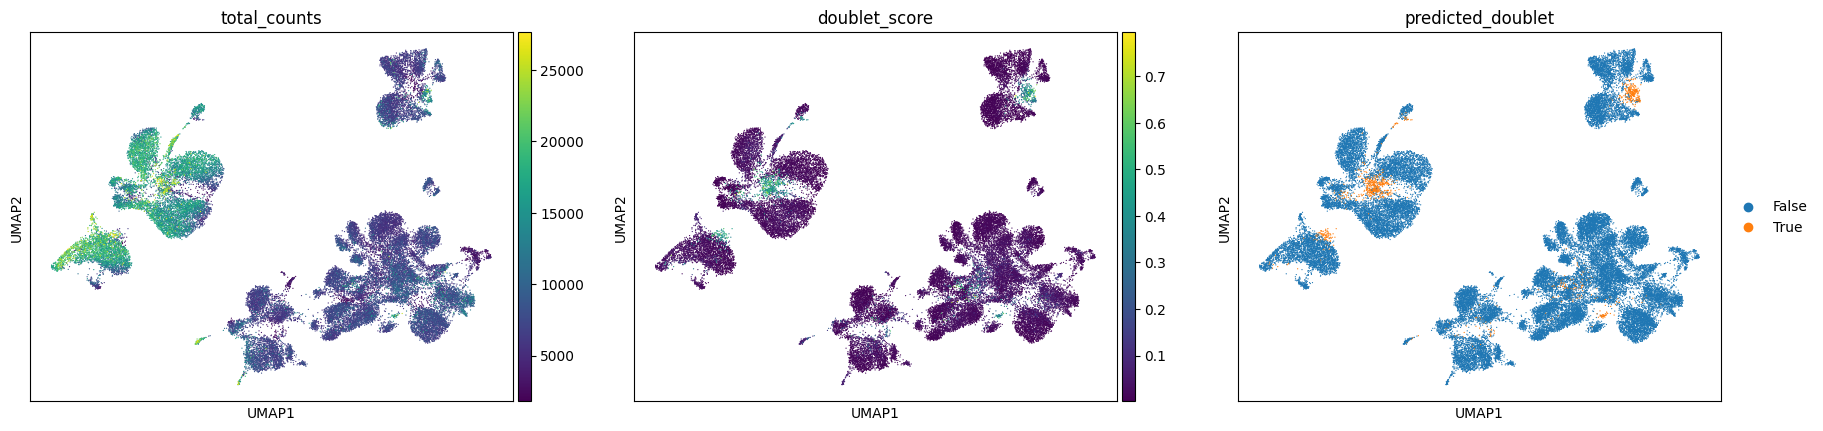

In [40]:
# inspecting quality control metrics
sc.pl.umap(
    adata,
    color=["total_counts", "doublet_score", "predicted_doublet"],
)

### Clustering

In [41]:
sc.tl.leiden(adata, key_added="leiden_res0_25", resolution=0.25)
sc.tl.leiden(adata, key_added="leiden_res0_5", resolution=0.5)
sc.tl.leiden(adata, key_added="leiden_res1", resolution=1.0)

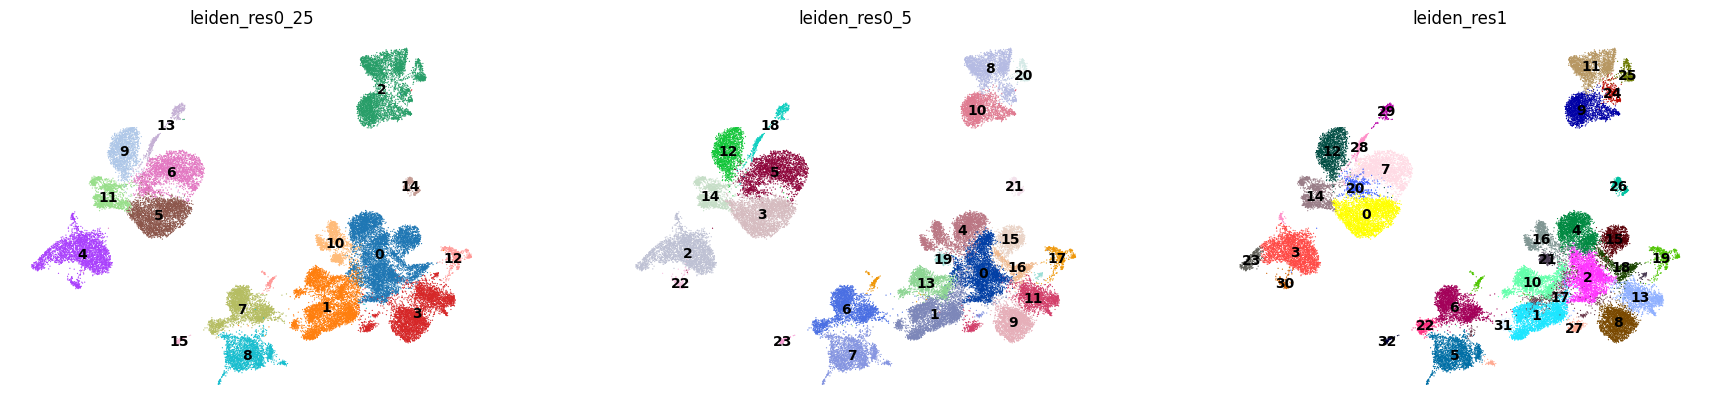

In [42]:
# inspect clustering
sc.pl.umap(
    adata,
    color=["leiden_res0_25", "leiden_res0_5", "leiden_res1"],
    legend_loc="on data",
    frameon=False
)

### Cell type annotation

In [ ]:
adata_celltypist = adata.copy()  # make a copy of our adata
adata_celltypist.X = adata.layers["corr"].copy()  # set adata.X to raw counts
sc.pp.normalize_total(
    adata_celltypist, target_sum=10**4
)  # normalize to 10,000 counts per cell
sc.pp.log1p(adata_celltypist)  # log-transform
# make .X dense instead of sparse, for compatibility with celltypist:
adata_celltypist.X = adata_celltypist.X.toarray()

In [44]:
# chose the right model based on the used dataset, defaults to PBCMs
models.download_models(
    force_update=True, model=["Adult_Human_PrefrontalCortex.pkl", "Immune_All_High.pkl", "Immune_All_Low.pkl"]
)

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 61
📂 Storing models in /home/luschroe/.celltypist/data/models
💾 Total models to download: 3
💾 Downloading model [1/3]: Immune_All_Low.pkl
💾 Downloading model [2/3]: Immune_All_High.pkl
💾 Downloading model [3/3]: Adult_Human_PrefrontalCortex.pkl


In [45]:
if dataset == "PFC":
    model = models.Model.load(model="Adult_Human_PrefrontalCortex.pkl")
else:
    model_high = models.Model.load(model="Immune_All_High.pkl")
    model_low = models.Model.load(model="Immune_All_Low.pkl")    

In [46]:
if dataset == "PFC":
    predictions = celltypist.annotate(
        adata_celltypist, model=model, majority_voting=True
    )
else:
    predictions_high = celltypist.annotate(
        adata_celltypist, model=model_high, majority_voting=True
    )
    predictions_low = celltypist.annotate(
        adata_celltypist, model=model_low, majority_voting=True
    )

🔬 Input data has 38720 cells and 38606 genes
🔗 Matching reference genes in the model
🧬 5824 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 15
🗳️ Majority voting the predictions
✅ Majority voting done!
🔬 Input data has 38720 cells and 38606 genes
🔗 Matching reference genes in the model
🧬 5824 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 15
🗳️ Majority voting the predictions
✅ Majority voting done!


In [47]:
if dataset == "PFC":
    predictions_adata = predictions.to_adata()
    adata.obs["celltypist_cell_label"] = predictions_adata.obs.loc[
        adata.obs.index, "majority_voting"
    ]
    adata.obs["celltypist_conf_score"] = predictions_adata.obs.loc[
        adata.obs.index, "conf_score"
    ]
else:
    predictions_high_adata = predictions_high.to_adata()
    adata.obs["celltypist_cell_label_coarse"] = predictions_high_adata.obs.loc[
        adata.obs.index, "majority_voting"
    ]
    adata.obs["celltypist_conf_score_coarse"] = predictions_high_adata.obs.loc[
        adata.obs.index, "conf_score"
    ]
    predictions_low_adata = predictions_low.to_adata()
    adata.obs["celltypist_cell_label_fine"] = predictions_low_adata.obs.loc[
        adata.obs.index, "majority_voting"
    ]
    adata.obs["celltypist_conf_score_fine"] = predictions_low_adata.obs.loc[
        adata.obs.index, "conf_score"
    ]

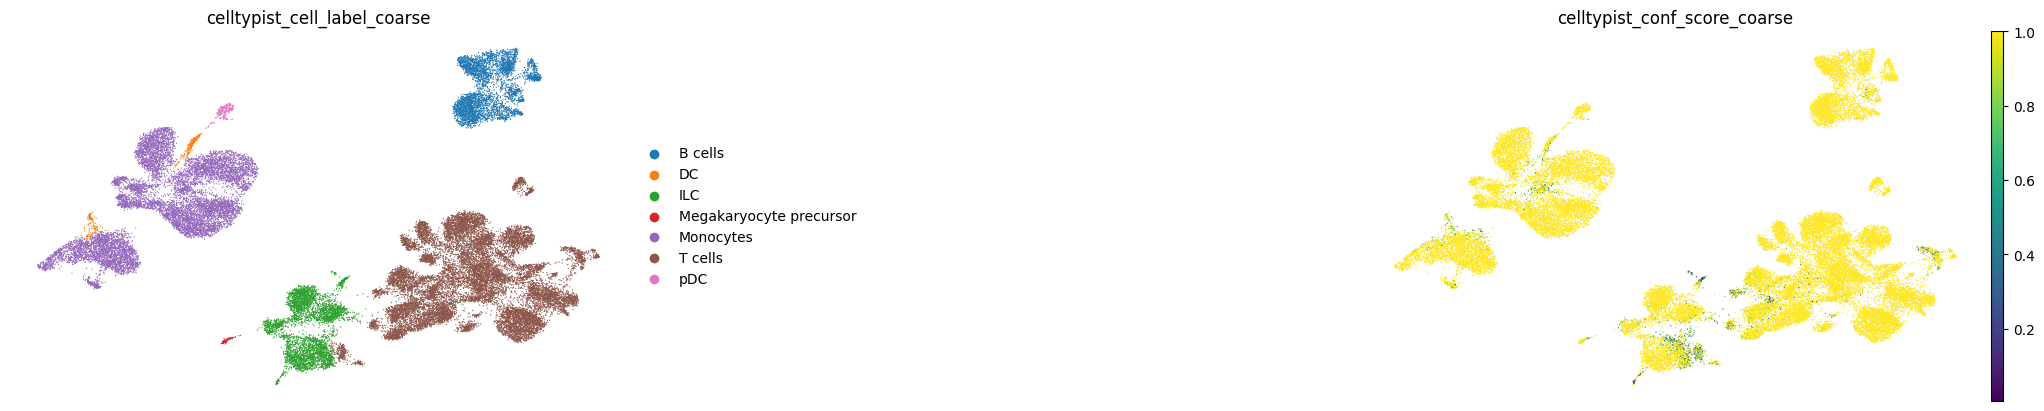

In [48]:
if dataset == "PFC":
    sc.pl.umap(
        adata,
        color=["celltypist_cell_label", "celltypist_conf_score"],
        frameon=False,
        sort_order=False,
        wspace=1,
    )
else:
    sc.pl.umap(
        adata,
        color=["celltypist_cell_label_coarse", "celltypist_conf_score_coarse"],
        frameon=False,
        sort_order=False,
        wspace=1,
    )

In [ ]:
# write output file
sc.write(f"{PATH}/{dataset}_soupx_processed.h5ad", adata)